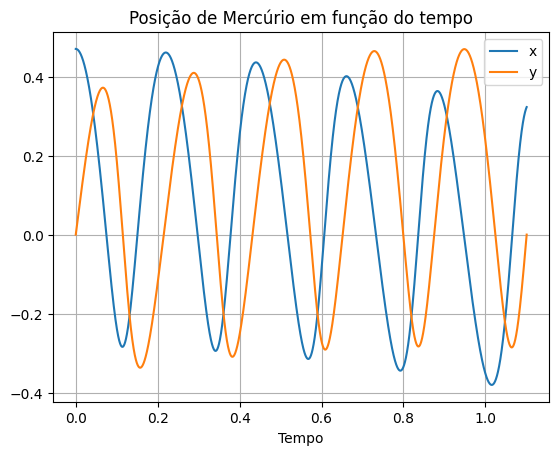

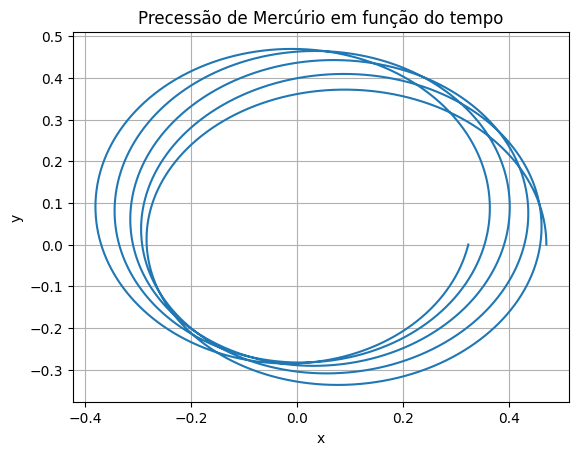

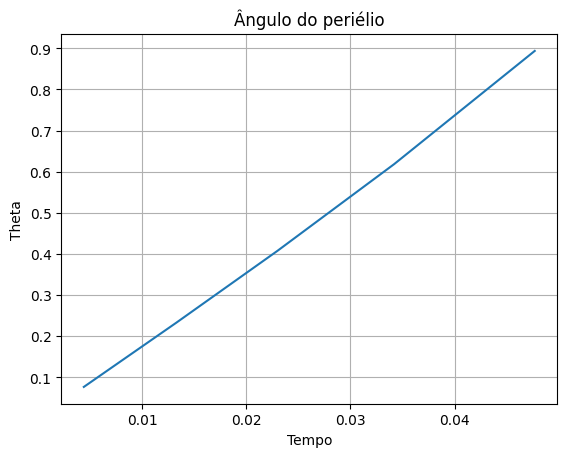

In [16]:
"""Questão 1"""

import numpy as np
import matplotlib.pyplot as plt

alpha=8.e-3
h=1.e-4
tempo=2
intervalos=int(tempo/h)
n=intervalos+1

t=np.linspace(0,tempo,n+1)
X=np.array([np.array([0.47, 0, 0, 8.2])])
voltas=0
r=np.array([])
ivoltas=np.array([])

def F(X):
    x,y,vx,vy = X[0], X[1], X[2], X[3]
    r=np.sqrt(x**2+y**2)
    f1=vx
    f2=vy
    f3=(-4*np.pi**2*x)/r**3-4*np.pi**2*alpha*x/r**5
    f4=(-4*np.pi**2*y)/r**3-4*np.pi**2*alpha*y/r**5
    return (np.array([f1,f2,f3,f4]),r)

for i in range(n):
    k1 = F(X[i])[0]
    k2 = F(X[i] + (1/2)*h*k1)[0]
    k3 = F(X[i] + (1/2)*h*k2)[0]
    k4 = F(X[i] + h*k3)[0]
    rk4 = np.array([X[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)])
    r=np.append(r,F(X[i])[1])
    if X[i,1]*rk4[0,1] < 0:
        voltas+=1
        ivoltas=np.append(ivoltas,i)
    if voltas==10:
        break
    X = np.concatenate((X, rk4), axis = 0)

t=t[0:i+1]
tr_min=[]
for i in range(0,voltas-1,2):
    minimo, maximo = int(ivoltas[i]), int(ivoltas[i+1])
    analise = r[minimo:maximo]
    tr_min = np.append(tr_min, np.argmin(analise))

tr_min = [int(tr_min[k]) for k in range(len(tr_min))]
y = X[:,1][tr_min]; x = X[:,0][tr_min]
tgtheta = y/x
theta = np.arctan(tgtheta)

tnew=t[tr_min]

plt.plot(t,X[:,0], label = "x")
plt.plot(t,X[:,1], label= "y")
plt.title("Posição de Mercúrio em função do tempo")
plt.xlabel("Tempo")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(X[:,0], X[:,1])
plt.title("Precessão de Mercúrio em função do tempo")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

plt.plot(tnew, theta)
plt.title("Ângulo do periélio")
plt.xlabel("Tempo")
plt.ylabel("Theta")
plt.grid(True)
plt.show()

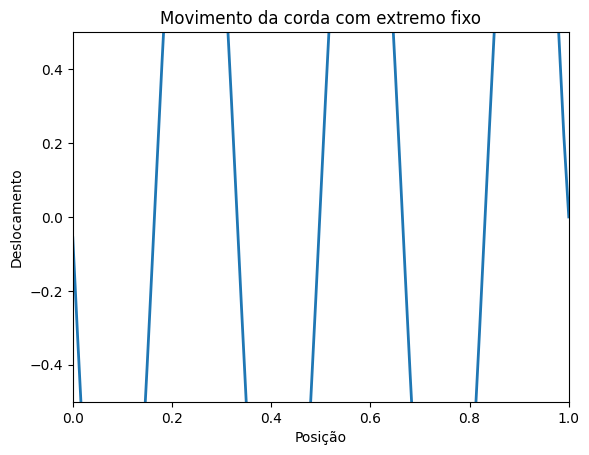

In [28]:
"""Questão 2(a)"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

L=1
c=300
r=1
f=900
omega=2*np.pi*f
A=0.3
M=100
dx=L/M
dt=dx/c

# C.I. corda
y = np.zeros((M+1, 3))
x = np.linspace(0, L, M+1)

#y(i=0)
def yi0(t):
    return A * np.sin(omega * t)

def calc_deslocamento(t):
    y[0,2]=yi0(t)
    a=2*(1-r**2)
    r2=r**2
    for i in range(1, M):
        y[i,2]=a*y[i,1]-y[i,0]+r2*(y[i+1,1]+y[i-1,1])
    #y[M,2] = y[M-1,2]  # Condição de extremidade livre
    y[:,0]=y[:,1]
    y[:,1]=y[:,2]
    return y

fig, ax = plt.subplots()
ax.set_xlim(0, L)
ax.set_ylim(-0.5, 0.5)
line, = ax.plot([], [], lw=2)

def init():
    line.set_data([], [])
    return line,

def animate(t):
    deslocamento = calc_deslocamento(t * dt)
    line.set_data(x, deslocamento[:, 2])
    return line,

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=500, interval=20, blit=True)

plt.xlabel('Posição')
plt.ylabel('Deslocamento')
plt.title('Movimento da corda com extremo fixo')
rc('animation', html='html5')
anim

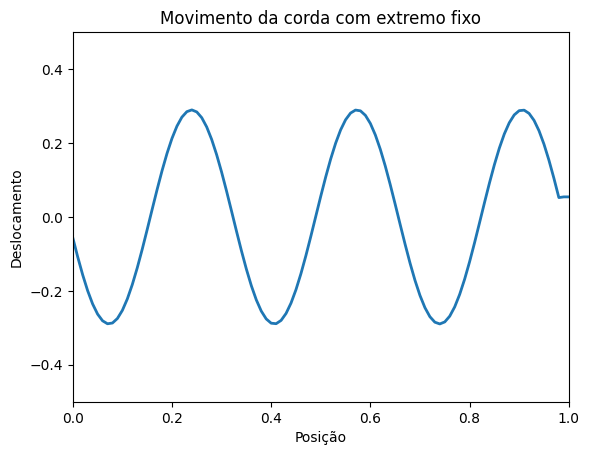

In [29]:
"""Questão 2(b)"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

L=1
c=300
r=1
f=900
omega=2*np.pi*f
A=0.3
M=100
dx=L/M
dt=dx/c

# C.I. corda
y = np.zeros((M+1, 3))
x = np.linspace(0, L, M+1)

#y(i=0)
def yi0(t):
    return A * np.sin(omega * t)

def calc_deslocamento(t):
    y[0,2]=yi0(t)
    a=2*(1-r**2)
    r2=r**2
    for i in range(1, M):
        y[i,2]=a*y[i,1]-y[i,0]+r2*(y[i+1,1]+y[i-1,1])
    y[M,2] = y[M-1,2]  # Condição de extremidade livre
    y[:,0]=y[:,1]
    y[:,1]=y[:,2]
    return y

fig, ax = plt.subplots()
ax.set_xlim(0, L)
ax.set_ylim(-0.5, 0.5)
line, = ax.plot([], [], lw=2)

def init():
    line.set_data([], [])
    return line,

def animate(t):
    deslocamento = calc_deslocamento(t * dt)
    line.set_data(x, deslocamento[:, 2])
    return line,

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=500, interval=20, blit=True)

plt.xlabel('Posição')
plt.ylabel('Deslocamento')
plt.title('Movimento da corda com extremo livre')
rc('animation', html='html5')
anim